# KNN algorithm from scratch



## The goals are:

1. Implement KNN algorithm from scratch (done in KNNFromScratch.py)
2. Visualization
3. Find best suited number k


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import sklearn
import KNNFromScratch

## Visualization

Let's visualize k nearest neighbours

In [13]:
dataset = sklearn.datasets.load_iris()

feature_names = dataset.feature_names
label_names = dataset.target_names

features = dataset.data
labels = dataset.target


setosas = np.array([features[i] for i in range(features.shape[0]) if labels[i] == 0])
versicolors = np.array([features[i] for i in range(features.shape[0]) if labels[i] == 1])
virginicas = np.array([features[i] for i in range(features.shape[0]) if labels[i] == 2])
print(feature_names)
print(label_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


### Project all the points onto 2D space

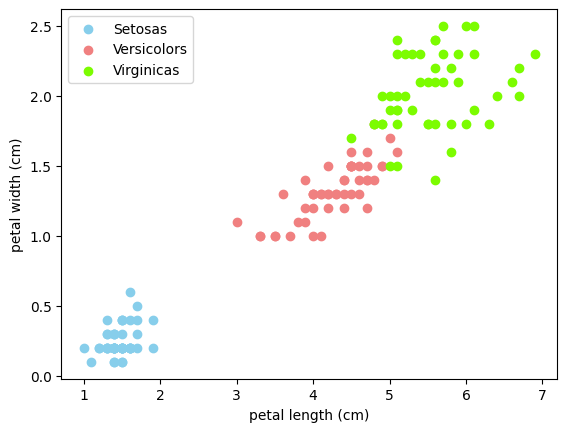

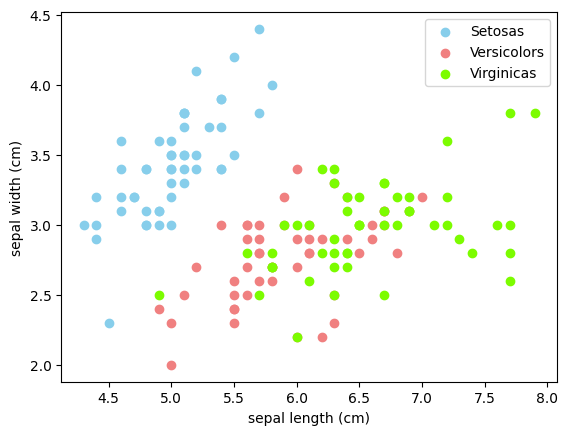

In [14]:
def scatter2features(i, j, feature_names):
    plt.scatter(setosas[:, i], setosas[:, j],
                color='skyblue',
                label='Setosas')
    plt.scatter(versicolors[:, i], versicolors[:, j],
                color='lightcoral',
                label='Versicolors')
    plt.scatter(virginicas[:, i], virginicas[:, j],
                color='lawngreen',
                label='Virginicas')
    plt.xlabel(feature_names[i])
    plt.ylabel(feature_names[j])
    plt.legend()
    

scatter2features(2, 3, feature_names)
plt.figure()
scatter2features(0, 1, feature_names)


### 5 nearest neighbours from point (5.5, 3.5, 2.5, 1)
Remember, the function calculates distance using all 4 coordinates.
Individual 2D scatter plots may be misleading.

In [15]:
k = 10
point = np.array([5.5, 3.5, 2.5, 1])

k_neighbours = KNNFromScratch.find_k_nearest_neighbours(k, point, features, labels)


In [16]:
# --- axes are sepal length and width ---
def plot_neighbours(point, k_neighbours, axes):
    xAxis, yAxis = axes
    # divide into groups
    k_neighbour_cords_setosa = np.array([neighbour[0] for neighbour in k_neighbours if neighbour[2] == 0])
    k_neighbour_cords_versicolor = np.array([neighbour[0] for neighbour in k_neighbours if neighbour[2] == 1])
    k_neighbour_cords_virginica = np.array([neighbour[0] for neighbour in k_neighbours if neighbour[2] == 2])
    
    predicted_group = KNNFromScratch.intToGroup(KNNFromScratch.knn_predict(k, point, features, labels))
    
    scatter2features(xAxis, yAxis, feature_names)
    if k_neighbour_cords_setosa.size != 0:
        plt.scatter(k_neighbour_cords_setosa[:, xAxis], k_neighbour_cords_setosa[:, yAxis],
                    label = 'Setosa neighbours',
                    color = 'darkblue')
    if k_neighbour_cords_versicolor.size != 0:
        plt.scatter(k_neighbour_cords_versicolor[:, xAxis], k_neighbour_cords_versicolor[:, yAxis],
                    label = 'Versicolor neighbours',
                    color = 'darkred')
    if k_neighbour_cords_virginica.size != 0:
        plt.scatter(k_neighbour_cords_virginica[:, xAxis], k_neighbour_cords_virginica[:, yAxis],
                    label = 'Virginica neighbours',
                    color = 'darkgreen')
    
    plt.scatter(point[xAxis], point[yAxis],
                label = 'Prediction: ' + predicted_group,
                color = 'magenta')
    plt.legend()


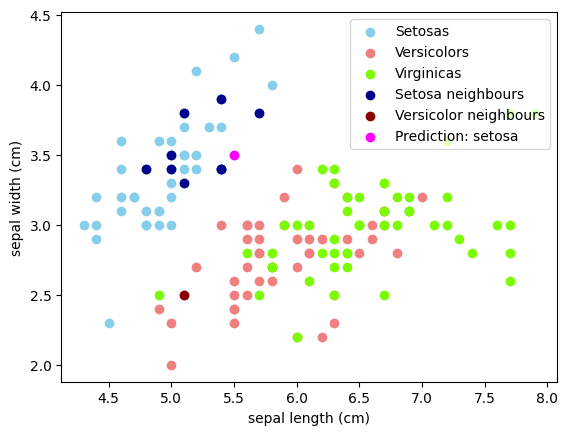

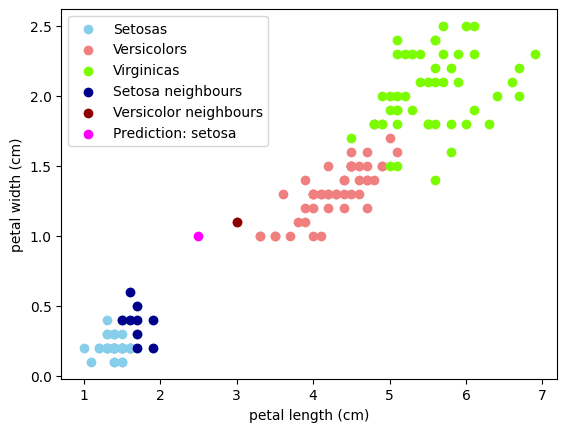

In [17]:
plot_neighbours(point, k_neighbours, (0, 1))
plt.figure()
plot_neighbours(point, k_neighbours, (2, 3))

## Find best k
To find best possible number k, we divide the data into n batches and look how good
the predictions are with different values of k from 1 to n

1. Shuffle the data

In [18]:
features_shuffled, labels_shuffled = KNNFromScratch.shuffle_data(features, labels)

2. Divide the data into train and test blocks

In [19]:
division_index = 120

features_train = features_shuffled[:division_index]
labels_train = labels_shuffled[:division_index]

features_test = features_shuffled[division_index:]
labels_test = labels_shuffled[division_index:]

3. Find which k has the best accuracy rate

In [20]:
number_of_batches = 5

k_range = 15
accuracies = [0 for i in range(k_range)]

for k in range(1, k_range + 1):
    success_num = 0
    
    for i in range(features_test.shape[0]):
        cords = features_test[i]
        label = labels_test[i]
        
        # count all successes in a batch    
        prediction = KNNFromScratch.knn_predict(k, cords, features_train, labels_train)

        if (prediction == label): 
            success_num += 1
            
    accuracy = success_num / features_test.shape[0]
    accuracies[k-1] = accuracy

for i in range(len(accuracies)):
    print('k = ' + str(i + 1) + ': ', end='')
    print(accuracies[i])
    


k = 1: 1.0
k = 2: 1.0
k = 3: 1.0
k = 4: 1.0
k = 5: 1.0
k = 6: 1.0
k = 7: 1.0
k = 8: 1.0
k = 9: 1.0
k = 10: 0.9666666666666667
k = 11: 0.9666666666666667
k = 12: 0.9666666666666667
k = 13: 0.9666666666666667
k = 14: 0.9666666666666667
k = 15: 1.0


4. Now do these steps 10 more times and find average.
   
To do that, we will turn each inner loop into a function.

In [21]:
def count_true_predictions(k, features_train, labels_train, features_test, labels_test):
    success_num = 0
    
    for i in range(features_test.shape[0]):
        cords = features_test[i]
        label = labels_test[i]
            
        # count all successes in a batch    
        prediction = KNNFromScratch.knn_predict(k, cords, features_train, labels_train)
    
        if (prediction == label): 
            success_num += 1
    return success_num

def add_accuracies(k_range, accuracies, features_train, labels_train, features_test, labels_test):
    
    for k in range(1, k_range + 1):
        success_num = count_true_predictions(k, features_train, labels_train, features_test, labels_test)
                
        accuracy = success_num / features_test.shape[0]
        accuracies[k-1] += accuracy
        
    return accuracies

In [22]:
cycles  = 25
k_range = 25
accuracies = [0 for i in range(k_range)]

for cycle in range(cycles):
    features_shuffled, labels_shuffled = KNNFromScratch.shuffle_data(features, labels)

    division_index = 120

    features_train = features_shuffled[:division_index]
    labels_train = labels_shuffled[:division_index]
    
    features_test = features_shuffled[division_index:]
    labels_test = labels_shuffled[division_index:]

    accuracies = add_accuracies(k_range, accuracies, features_train, labels_train, features_test, labels_test)

accuracies_average = [accuracy / cycles for accuracy in accuracies]



### Create bar plot

(0.9269999999999997, 0.9716666666666663)

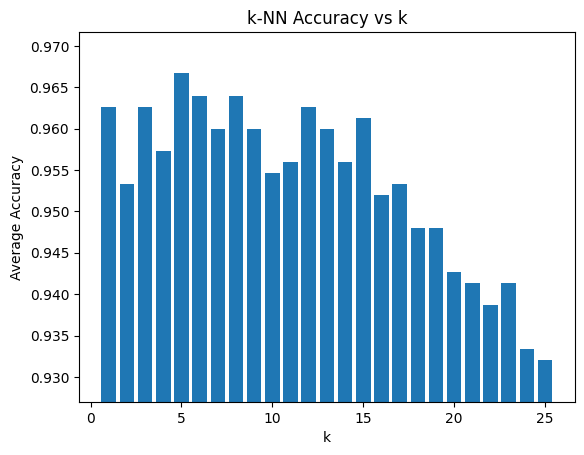

In [23]:
k_values = list(range(1, k_range + 1))

plt.figure()
plt.bar(k_values, accuracies_average)

plt.xlabel("k")
plt.ylabel("Average Accuracy")
plt.title("k-NN Accuracy vs k")

plt.ylim(min(accuracies_average) - 0.005,
         max(accuracies_average) + 0.005)

## Analysis

Overall the KNN algorithm does a good job separating groups.

### k = 14 is the best choice. 
- It's big enough to avoid overfitting.
- And small enough, so that KNN algorithm isn't too slow.